# Autoencoder PyTorch — Détection d'Anomalies Réseau
## Objectif
Construire un Autoencoder qui apprend le trafic normal CESNET
et détecte les anomalies par erreur de reconstruction élevée.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Charger les données
X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')

# Convertir en tenseurs PyTorch
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)

print(f"X_train tensor : {X_train_tensor.shape}")
print(f"X_test tensor  : {X_test_tensor.shape}")
print("Tenseurs créés ")

Device : cpu
X_train tensor : torch.Size([762157, 12])
X_test tensor  : torch.Size([190540, 12])
Tenseurs créés 


In [2]:
# Architecture Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim=12):
        super(Autoencoder, self).__init__()
        
        # Encoder : 12 → 8 → 4
        self.encoder = nn.Sequential(
            nn.Linear(12, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )
        
        # Decoder : 4 → 8 → 12
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 12)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Créer le modèle
model = Autoencoder().to(device)

# Afficher l'architecture
print(model)
print(f"\nNombre de paramètres : {sum(p.numel() for p in model.parameters())}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=12, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=12, bias=True)
  )
)

Nombre de paramètres : 288


In [3]:
# DataLoader
dataset = TensorDataset(X_train_tensor, X_train_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

# Loss et Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Entraînement
epochs = 50
losses = []

print("Début de l'entraînement...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, _ in dataloader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 — Loss : {avg_loss:.6f}")

print("\nEntraînement terminé ")

Début de l'entraînement...
Epoch 10/50 — Loss : 0.042745
Epoch 20/50 — Loss : 0.041878
Epoch 30/50 — Loss : 0.041191
Epoch 40/50 — Loss : 0.040213
Epoch 50/50 — Loss : 0.039763

Entraînement terminé 


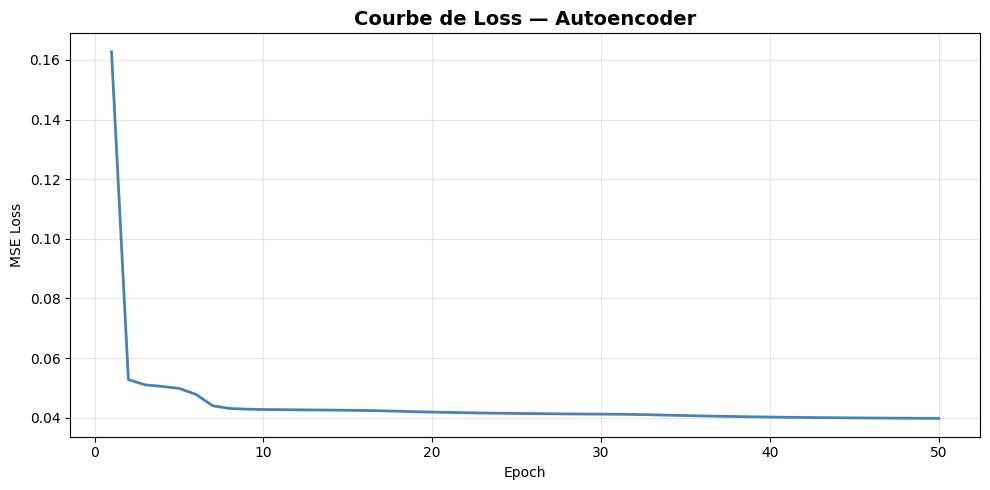

Modèle sauvegardé : models/autoencoder.pth 


In [4]:
# Courbe de loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), losses, color='steelblue', linewidth=2)
plt.title('Courbe de Loss — Autoencoder', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notes/loss_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Sauvegarder le modèle
torch.save(model.state_dict(), '../models/autoencoder.pth')
print("Modèle sauvegardé : models/autoencoder.pth ")

In [5]:
# Calculer les erreurs de reconstruction
model.eval()
with torch.no_grad():
    # Erreurs sur X_train
    X_train_pred = model(X_train_tensor)
    train_errors = torch.mean((X_train_tensor - X_train_pred) ** 2, dim=1).numpy()
    
    # Erreurs sur X_test
    X_test_pred = model(X_test_tensor)
    test_errors = torch.mean((X_test_tensor - X_test_pred) ** 2, dim=1).numpy()

# Définir le seuil
threshold = np.percentile(train_errors, 95)
print(f"Seuil d'anomalie (95e percentile) : {threshold:.6f}")
print(f"\nErreurs train — min : {train_errors.min():.6f}, max : {train_errors.max():.6f}, mean : {train_errors.mean():.6f}")
print(f"Erreurs test  — min : {test_errors.min():.6f}, max : {test_errors.max():.6f}, mean : {test_errors.mean():.6f}")

# Classifier
predictions = (test_errors > threshold).astype(int)
anomalies = predictions.sum()
print(f"\nAnomalies détectées : {anomalies} / {len(predictions)} ({anomalies/len(predictions)*100:.1f}%)")

Seuil d'anomalie (95e percentile) : 0.120957

Erreurs train — min : 0.000296, max : 2.147956, mean : 0.039770
Erreurs test  — min : 0.000484, max : 0.905729, mean : 0.077409

Anomalies détectées : 46820 / 190540 (24.6%)


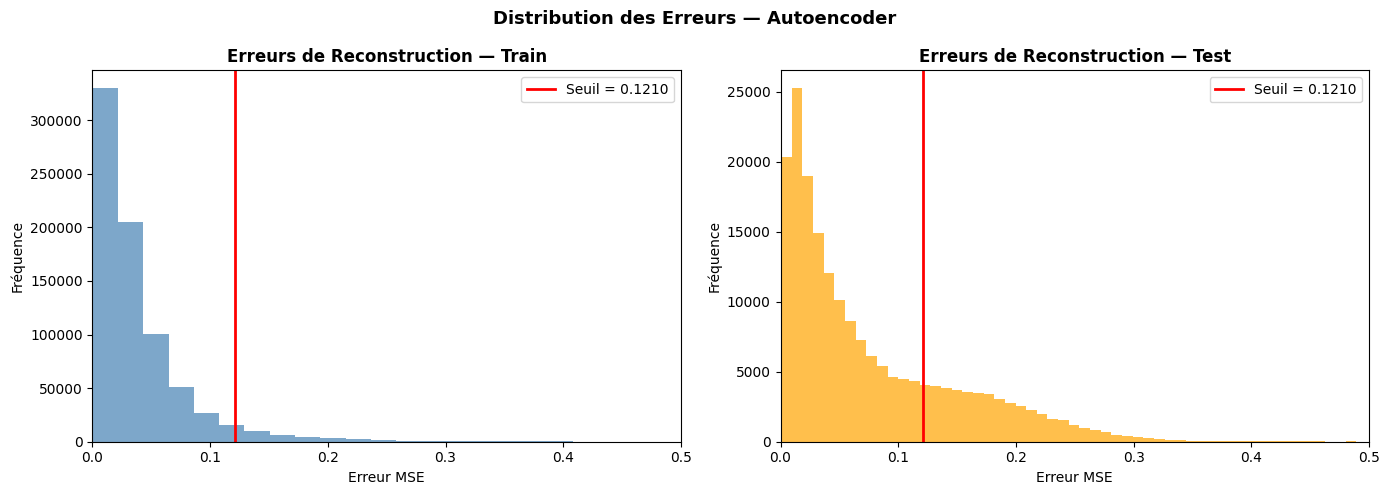

Graphique sauvegardé 


In [7]:
# Distribution des erreurs de reconstruction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train errors
axes[0].hist(train_errors, bins=100, color='steelblue', alpha=0.7)
axes[0].axvline(threshold, color='red', linewidth=2, label=f'Seuil = {threshold:.4f}')
axes[0].set_title('Erreurs de Reconstruction — Train', fontweight='bold')
axes[0].set_xlabel('Erreur MSE')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].set_xlim(0, 0.5)

# Test errors
axes[1].hist(test_errors, bins=100, color='orange', alpha=0.7)
axes[1].axvline(threshold, color='red', linewidth=2, label=f'Seuil = {threshold:.4f}')
axes[1].set_title('Erreurs de Reconstruction — Test', fontweight='bold')
axes[1].set_xlabel('Erreur MSE')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].set_xlim(0, 0.5)

plt.suptitle('Distribution des Erreurs — Autoencoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/reconstruction_errors.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")

In [8]:
# Sauvegarder le seuil
import json

config = {
    'threshold': float(threshold),
    'input_dim': 12,
    'features': ['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn',
                 'n_dest_ports', 'n_dest_ip', 'tcp_udp_ratio_packets',
                 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes',
                 'avg_duration', 'avg_ttl'],
    'skewed_features': ['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn',
                        'n_dest_ports', 'n_dest_ip', 'avg_duration']
}

with open('../models/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"Config sauvegardée ")
print(f"Threshold : {threshold:.6f}")

Config sauvegardée 
Threshold : 0.120957


In [10]:
import sys
sys.path.append('../')
from utils.predictor import predict
import pandas as pd

# Charger un petit échantillon pour tester
df_test = pd.read_csv('../data/cesnet_sample.csv').head(100)

# Tester la fonction predict
result = predict(df_test)

print(f"Total connexions  : {len(df_test)}")
print(f"Anomalies         : {result['n_anomalies']}")
print(f"Normal            : {result['n_normal']}")
print(f"Taux d'anomalies  : {result['anomaly_rate']:.1f}%")
print(f"Threshold         : {result['threshold']:.6f}")
print(f"\nPremières erreurs : {result['errors'][:5]}")
print("\nPredictor fonctionne parfaitement ")

Total connexions  : 100
Anomalies         : 4
Normal            : 96
Taux d'anomalies  : 4.0%
Threshold         : 0.120957

Premières erreurs : [0.01424169 0.03462209 0.02279577 0.00855036 0.0117947 ]

Predictor fonctionne parfaitement 


c:\Users\chouc\anaconda3\envs\cesnet\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [12]:
result = predict(df_test)
print(f"Anomalies : {result['n_anomalies']} / {len(df_test)}")
print("Predictor sans warnings ")

Anomalies : 4 / 100
Predictor sans warnings 


c:\Users\chouc\anaconda3\envs\cesnet\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
